#LabWeek9: Prevent Overfitting - Part I

## Importing Dataset: IMDB

In [1]:
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] += 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Note:** We first encountered this dataset in `LabWeek5`. You can refer to that notebook for clarification on the text-to-numbers decoding process. Through vectorizing process we turn text data into vectors.

**Perform some sanity checks on the dataset:** For example, find the `shape` of the dataset and print samples to make sense of the data.

In [2]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFirst training sample (first 50 values):", x_train[0][:50])
print("First training label:", y_train[0])

print("\nLabel distribution - Train:", np.unique(y_train, return_counts=True))
print("Label distribution - Test:", np.unique(y_test, return_counts=True))

x_train shape: (25000, 10000)
x_test shape: (25000, 10000)
y_train shape: (25000,)
y_test shape: (25000,)

First training sample (first 50 values): [ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.  0.  0.  6.  3.  3.  4. 11.  3.
  3.  2.  0.  1.  6.  0.  0.  4.  3.  0.  2.  0.  1.  0.  3.  2.  0.  1.
  4.  0.  4.  1.  0.  0.  0.  4.  0.  0.  1.  0.  1.  0.]
First training label: 1.0

Label distribution - Train: (array([0., 1.], dtype=float32), array([12500, 12500]))
Label distribution - Test: (array([0., 1.], dtype=float32), array([12500, 12500]))


## Fighting overfitting -  Reducing the network's size


The general workflow to find an appropriate model size is to start with relatively few layers and
parameters, and start increasing the size of the layers or adding new layers until you see diminishing returns with regard to the
validation loss.



**Note:** we use `test set` as our `validation set`.

**Complete the following code for `original model` architecture**

In [3]:
from keras import models
from keras import layers

original_model = models.Sequential()
original_model.add(layers.InputLayer(shape=(10000,)))
original_model.add(layers.Dense(16, activation='relu'))
original_model.add(layers.Dense(16, activation='relu'))
original_model.add(layers.Dense(1, activation='sigmoid'))

original_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])

In [4]:
original_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

**Define another model with fewer parameters. 4 units in each hidden layer.**

In [5]:
smaller_model = models.Sequential()
smaller_model.add(layers.InputLayer(shape=(10000,)))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(1, activation='sigmoid'))

smaller_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['acc'])


**Train (1) original_model and (2) smaller_model seperately for `epochs=20` and `batch_size=512`. Also pass `x_test` and `y_test` as `validation_data`.**

In [6]:
original_hist = original_model.fit(x_train, y_train,
                                   epochs=20,
                                   batch_size=512,
                                   validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - acc: 0.7884 - loss: 0.4875 - val_acc: 0.8690 - val_loss: 0.3658
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.8930 - loss: 0.3059 - val_acc: 0.8833 - val_loss: 0.3138
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.9152 - loss: 0.2398 - val_acc: 0.8732 - val_loss: 0.3242
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.9249 - loss: 0.2102 - val_acc: 0.8852 - val_loss: 0.2964
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9346 - loss: 0.1851 - val_acc: 0.8797 - val_loss: 0.3152
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9422 - loss: 0.1631 - val_acc: 0.8632 - val_loss: 0.3728
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.9448 - loss: 0.1550 - val_acc: 0.8762 - val_loss: 0.3348
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9540 - loss: 0.1345 - val_acc: 0.8585 - val_loss: 0.4073
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - acc: 0.956

In [7]:
smaller_hist = smaller_model.fit(x_train, y_train,
                                 epochs=20,
                                 batch_size=512,
                                 validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - acc: 0.6476 - loss: 0.6355 - val_acc: 0.7364 - val_loss: 0.5833
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.8086 - loss: 0.5368 - val_acc: 0.7876 - val_loss: 0.5290
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.8627 - loss: 0.4808 - val_acc: 0.8391 - val_loss: 0.4876
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.8915 - loss: 0.4371 - val_acc: 0.8747 - val_loss: 0.4435
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9136 - loss: 0.3483 - val_acc: 0.8820 - val_loss: 0.3518
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - acc: 0.9243 - loss: 0.2591 - val_acc: 0.8838 - val_loss: 0.3121
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9318 - loss: 0.2178 - val_acc: 0.8888 - val_loss: 0.2910
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9390 - loss: 0.1914 - val_acc: 0.8879 - val_loss: 0.2872
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - acc: 0.9440

**`orginal_hist` and `smaller_hist` are `objects` returned after training the models.**
- We can get access to the `history` attribute of `origial_hist` object through dot operator.
- TODO: The history attribute is a data structure of type `dictionary` containing data about everything that happened during training. Show the `keys` of this `dictionary`.

In [8]:
print(original_hist.history)
print(original_hist.history.keys())

{'acc': [0.7883999943733215, 0.8930400013923645, 0.9151999950408936, 0.9249200224876404, 0.9345999956130981, 0.9422399997711182, 0.9448000192642212, 0.954039990901947, 0.9561600089073181, 0.9589599967002869, 0.963919997215271, 0.9662799835205078, 0.9696000218391418, 0.9729599952697754, 0.9750400185585022, 0.976639986038208, 0.9800000190734863, 0.9816799759864807, 0.9817600250244141, 0.9831600189208984], 'loss': [0.48747989535331726, 0.3059418201446533, 0.23983924090862274, 0.2102341651916504, 0.18510647118091583, 0.16309890151023865, 0.15503913164138794, 0.13449537754058838, 0.12644483149051666, 0.1174638569355011, 0.10773950815200806, 0.09946677833795547, 0.09405939280986786, 0.08291711658239365, 0.07770048081874847, 0.07196450233459473, 0.06403575837612152, 0.06069359928369522, 0.05755802243947983, 0.056442875415086746], 'val_acc': [0.8690400123596191, 0.8832799792289734, 0.873199999332428, 0.8851600289344788, 0.8796799778938293, 0.8632000088691711, 0.8761600255966187, 0.858519971370

**Plot `val_loss` vs. epochs for both models in one plot**

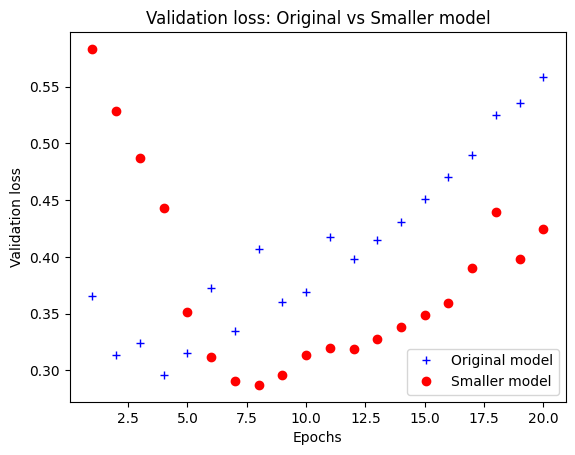

In [9]:
from matplotlib import pyplot as plt

epochs = range(1, 21)

original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']

plt.plot(epochs, original_val_loss, 'b+', label='Original model')
plt.plot(epochs, smaller_val_loss, 'ro', label='Smaller model')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: Original vs Smaller model')
plt.legend()
plt.show()

**Plot training `loss` vs. epochs for both models in one plot**

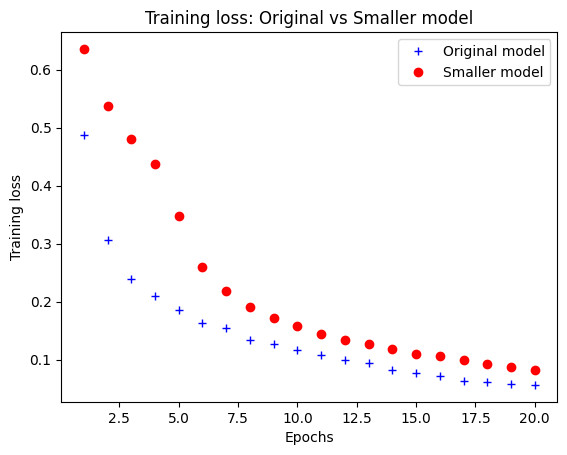

In [10]:
original_train_loss = original_hist.history['loss']
smaller_train_loss = smaller_hist.history['loss']

plt.plot(epochs, original_train_loss, 'b+', label='Original model')
plt.plot(epochs, smaller_train_loss, 'ro', label='Smaller model')
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.title('Training loss: Original vs Smaller model')
plt.legend()
plt.show()

**Questions:** Which model overfits earlier? How can you see the size of the model on overfitting?

**Answer:** The original model (16 units per hidden layer) overfits earlier than the smaller model (4 units per hidden layer). We can see this because the original model's validation loss starts increasing sooner while its training loss continues to decrease, indicating a growing gap between training and validation performance. The larger the model (more parameters), the faster it memorizes the training data and the sooner overfitting begins. The smaller model, with fewer parameters, is more constrained and thus takes longer to overfit.

**Now define a very large model (e.g., with 512 units in hidden layer) and compare the `loss` and `val_loss` of this big model and the `original model` and `smaller_model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 368ms/step - acc: 0.7380 - loss: 0.5962 - val_acc: 0.7328 - val_loss: 0.5845
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 328ms/step - acc: 0.8645 - loss: 0.3366 - val_acc: 0.8860 - val_loss: 0.2877
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - acc: 0.9032 - loss: 0.2497 - val_acc: 0.8679 - val_loss: 0.3307
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - acc: 0.9180 - loss: 0.2098 - val_acc: 0.8861 - val_loss: 0.2833
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - acc: 0.9366 - loss: 0.1655 - val_acc: 0.8008 - val_loss: 0.5066
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - acc: 0.9498 - loss: 0.1327 - val_acc: 0.8657 - val_loss: 0.3588
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - acc: 0.9623 - loss: 0.1050 - val_acc: 0.8854 - val_loss: 0.2859
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 335ms/step - acc: 0.9824 - loss: 0.0725 - val_acc: 0.8844 - val_loss: 0.3879
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 334ms/

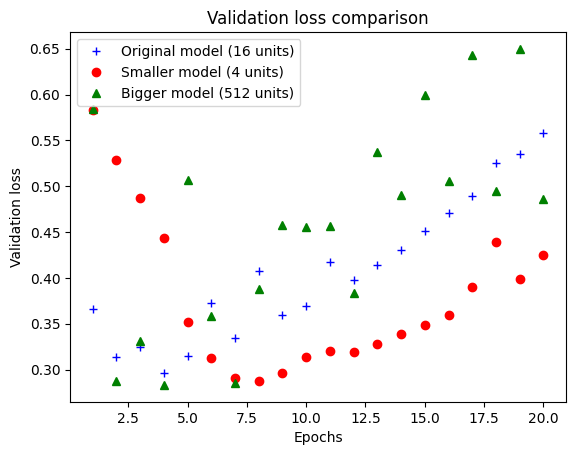

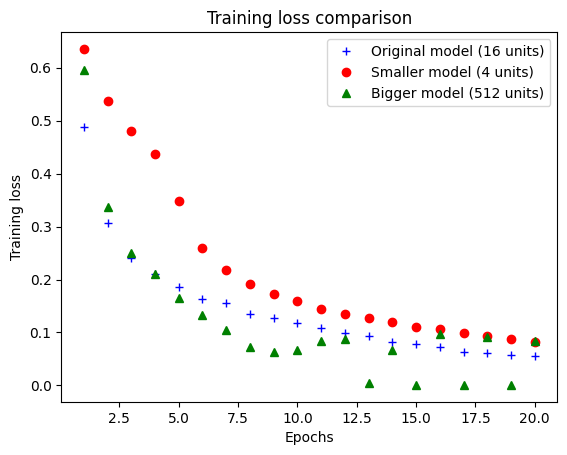

In [11]:
bigger_model = models.Sequential()
bigger_model.add(layers.InputLayer(shape=(10000,)))
bigger_model.add(layers.Dense(512, activation='relu'))
bigger_model.add(layers.Dense(512, activation='relu'))
bigger_model.add(layers.Dense(1, activation='sigmoid'))

bigger_model.compile(optimizer='rmsprop',
                     loss='binary_crossentropy',
                     metrics=['acc'])

bigger_hist = bigger_model.fit(x_train, y_train,
                               epochs=20,
                               batch_size=512,
                               validation_data=(x_test, y_test))

# Plot validation loss for all three models
bigger_val_loss = bigger_hist.history['val_loss']

plt.plot(epochs, original_val_loss, 'b+', label='Original model (16 units)')
plt.plot(epochs, smaller_val_loss, 'ro', label='Smaller model (4 units)')
plt.plot(epochs, bigger_val_loss, 'g^', label='Bigger model (512 units)')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss comparison')
plt.legend()
plt.show()

# Plot training loss for all three models
bigger_train_loss = bigger_hist.history['loss']

plt.plot(epochs, original_train_loss, 'b+', label='Original model (16 units)')
plt.plot(epochs, smaller_train_loss, 'ro', label='Smaller model (4 units)')
plt.plot(epochs, bigger_train_loss, 'g^', label='Bigger model (512 units)')
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.title('Training loss comparison')
plt.legend()
plt.show()

**Discuss the results**

**Answer:** The bigger model (512 units) overfits almost immediately — its training loss drops to near zero very quickly, while its validation loss increases rapidly after just a few epochs. The gap between training and validation loss is much larger for the bigger model compared to the original and smaller models. This demonstrates that higher-capacity networks can memorize training data faster but generalize worse. The smaller model shows the most gradual overfitting with the smallest gap between training and validation loss. This confirms that reducing network size is an effective strategy to combat overfitting.

## Fighting overfitting - Adding weight regularization


A common way to mitigate overfitting is to put constraints on the complexity
of a network by forcing its weights to only take small values. This is called
"weight regularization", and it is done by adding to the loss function of the network a _cost_ associated with having large weights. This
cost comes in two flavors:

* L1 regularization, where the cost added is proportional to the _absolute value of the weights coefficients_ (i.e. to what is called the
"L1 norm" of the weights).
* L2 regularization, where the cost added is proportional to the _square of the value of the weights coefficients_ (i.e. to what is called
the "L2 norm" of the weights). L2 regularization is also called _weight decay_ in the context of neural networks. Don't let the different
name confuse you: weight decay is mathematically the exact same as L2 regularization.

In Keras, weight regularization is added by passing _weight regularizer instances_ to layers as keyword arguments.


**Complere the model below**

In [12]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.InputLayer(shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

In [13]:
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value` to the total loss of
the network. Note that because this penalty is _only added at training time_, the loss for this network will be much higher at training
than at test time.



**Train the model with regularization and compare the validation loss between this model and the `original_model` and `smaller model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - acc: 0.7765 - loss: 0.5573 - val_acc: 0.8405 - val_loss: 0.4628
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.8889 - loss: 0.3710 - val_acc: 0.8822 - val_loss: 0.3658
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9058 - loss: 0.3094 - val_acc: 0.8610 - val_loss: 0.3966
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - acc: 0.9154 - loss: 0.2844 - val_acc: 0.8884 - val_loss: 0.3342
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9242 - loss: 0.2634 - val_acc: 0.8751 - val_loss: 0.3710
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9255 - loss: 0.2573 - val_acc: 0.8881 - val_loss: 0.3391
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - acc: 0.9325 - loss: 0.2454 - val_acc: 0.8793 - val_loss: 0.3614
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.9315 - loss: 0.2431 - val_acc: 0.8436 - val_loss: 0.4786
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - acc: 0.9372

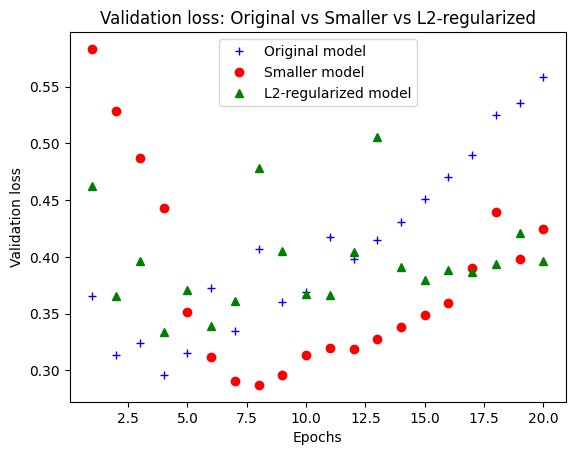

In [14]:
l2_hist = l2_model.fit(x_train, y_train,
                       epochs=20,
                       batch_size=512,
                       validation_data=(x_test, y_test))

l2_val_loss = l2_hist.history['val_loss']

plt.plot(epochs, original_val_loss, 'b+', label='Original model')
plt.plot(epochs, smaller_val_loss, 'ro', label='Smaller model')
plt.plot(epochs, l2_val_loss, 'g^', label='L2-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: Original vs Smaller vs L2-regularized')
plt.legend()
plt.show()

**Note:** As alternatives to L2 regularization, you could use one of the following Keras weight regularizers:

In [15]:
from keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# L1 and L2 regularization at the same time
regularizers.l1_l2(l1=0.001, l2=0.001)

## Recap

To recap: here the most common ways to prevent overfitting in neural networks:

* Getting more training data.
* Reducing the capacity of the network.
* Adding weight regularization.
* Adding dropout. (next session)

**Observation 1:** The bigger network gets its training loss near zero very quickly. The more capacity the network has, the quicker it will be
able to model the training data (resulting in a low training loss), but the more susceptible it is to overfitting (resulting in a large
difference between the training and validation loss).

**Observation 2:** The model with L2 regularization has become much more resistant to overfitting than the reference model,
even though both models have the same number of parameters.